# Correlation between EURUSD and GBPUSD

Correlation Matrix:
        EURUSD  GBPUSD  XAUUSD
EURUSD    1.00    0.75    0.14
GBPUSD    0.75    1.00    0.16
XAUUSD    0.14    0.16    1.00


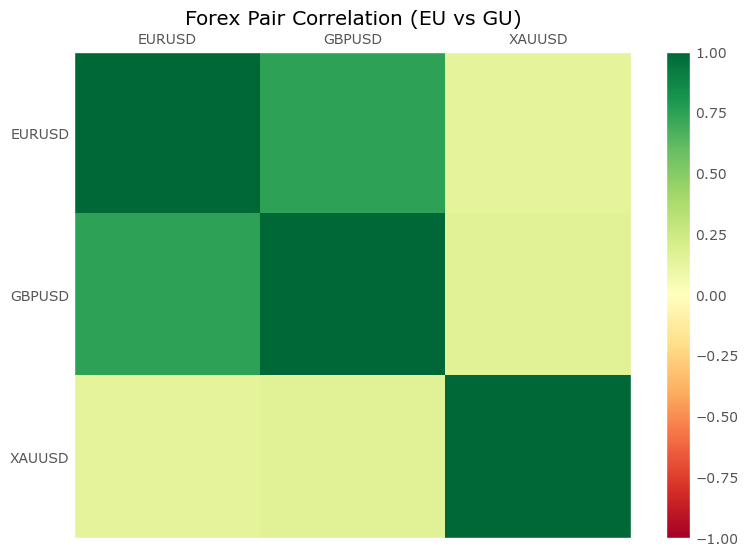

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Using 'ggplot' for a clean, professional aesthetic without extra code
plt.style.use('ggplot')

# --- 1. DATA SYNTHESIS ---
# We seed the generator so our "random" results are consistent every time we run it
np.random.seed(42)
days = 100

# We simulate the USD as the "Master Variable" that drives the other pairs
usd_strength = np.random.normal(0, 0.01, days) 

# Forex Logic: Since USD is the quote currency (XXX/USD), a strong dollar
# pushes the pair returns DOWN. We add minor 'noise' to simulate market reality.
eu_returns = -usd_strength + np.random.normal(0, 0.005, days)
gu_returns = -usd_strength + np.random.normal(0, 0.005, days)

# Gold is highly volatile and less tied to the USD in this specific simulation
gold_returns = np.random.normal(0, 0.02, days)

# Bundle our series into a DataFrame for matrix calculations
df = pd.DataFrame({
    'EURUSD': eu_returns,
    'GBPUSD': gu_returns,
    'XAUUSD': gold_returns
})

# --- 2. THE CORRELATION MATRIX ---
# Calculates the Pearson correlation (-1 to 1) between all pairs
corr_table = df.corr()

# Helpful for the console: Quick check to see the math is working
print("Correlation Matrix:")
print(corr_table.round(2))

# --- 3. VISUALIZATION ---
plt.figure(figsize=(8, 6))

# pcolor creates the grid. vmin/vmax ensures the color scale stays 
# anchored between -1 (Red) and 1 (Green) regardless of the data.
heatmap = plt.pcolor(corr_table, cmap=plt.cm.RdYlGn, vmin=-1, vmax=1)
plt.colorbar(heatmap)

# Align labels to the center of the squares (0.5 offset)
# This prevents the text from being stuck on the grid lines
plt.xticks(np.arange(0.5, len(corr_table.columns), 1), corr_table.columns)
plt.yticks(np.arange(0.5, len(corr_table.index), 1), corr_table.index)

plt.gca().invert_yaxis()
plt.gca().xaxis.tick_top()

plt.title('Forex Pair Correlation (EU vs GU)')
plt.show()


        EURUSD  USDJPY  AUDUSD  GBPUSD
EURUSD    1.00    0.26    0.44    1.00
USDJPY    0.26    1.00   -0.63    0.28
AUDUSD    0.44   -0.63    1.00    0.45
GBPUSD    1.00    0.28    0.45    1.00


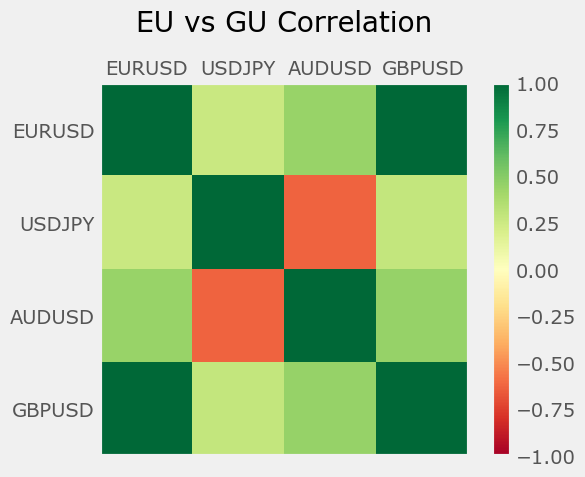

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
plt.style.use('fivethirtyeight')

# Simulated daily close prices for EU and GU
# Realistic values - EU typically 1.08-1.12, GU typically 1.26-1.30
data = {
    'EURUSD': [1.081, 1.085, 1.090, 1.088, 1.092],
    'USDJPY': [148.5, 149.1, 147.8, 150.2, 149.8],  # inverse - USD is base
    'AUDUSD': [0.651, 0.648, 0.655, 0.649, 0.652], # weakly correlated
    'GBPUSD': [1.261, 1.265, 1.271, 1.269, 1.274],
}

df = pd.DataFrame(data)

# Correlation matrix
df_corr = df.corr()
print(df_corr.round(2))

# Heatmap
values = df_corr.values

plt.figure(figsize=(6, 5))
ax = plt.gca()

heatmap = ax.pcolor(values, cmap=plt.cm.RdYlGn)
plt.colorbar(heatmap)

ax.set_xticks(np.arange(values.shape[0]) + 0.5)
ax.set_yticks(np.arange(values.shape[1]) + 0.5)
ax.invert_yaxis()
ax.xaxis.tick_top()

ax.set_xticklabels(df_corr.columns)
ax.set_yticklabels(df_corr.index)

heatmap.set_clim(-1, 1)
plt.title('EU vs GU Correlation', pad=20)
plt.tight_layout()
plt.show()
